In [1]:
import pandas as pd

# Paths to your datasets
fc_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_withinbetween_fcrsn7_artifact_pfactor_filter_harmonized.tsv"
gv_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_gv_artifact_pfactor_filter_harmonized.tsv"
ct_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_ct_artifact_pfactor_filter_harmonized.tsv"

# Load the datasets
df_fc = pd.read_csv(fc_path, sep="\t")  # Functional Connectivity
df_gv = pd.read_csv(gv_path, sep="\t")  # Graph Variance
df_ct = pd.read_csv(ct_path, sep="\t")  # Cortical Thickness

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10591/3010488767.py:10: DtypeWarning: Columns (405) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gv = pd.read_csv(gv_path, sep="\t")  # Graph Variance
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10591/3010488767.py:11: DtypeWarning: Columns (405) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ct = pd.read_csv(ct_path, sep="\t")  # Cortical Thickness


In [1]:
import sys
print(sys.version)
print(sys.executable)

3.9.13 (main, Aug 25 2022, 18:29:29) 
[Clang 12.0.0 ]
/Users/ujjwalsamanta/opt/anaconda3/bin/python


In [2]:
df_fc['parent_2_education'].isnull().sum()

278

In [3]:
# ============================================================
#  New cell: Investigate parent_1 vs parent_2 missingness
#  (before df_fc_cleaned drops parent_1_education)
# ============================================================
n_total = len(df_fc)

n_p1_only = df_fc['parent_1_education'].notna().sum()
n_p2_only = df_fc['parent_2_education'].notna().sum()
n_either  = df_fc[['parent_1_education', 'parent_2_education']].notna().any(axis=1).sum()
n_both    = df_fc[['parent_1_education', 'parent_2_education']].notna().all(axis=1).sum()

print(f"Total participants (in df_fc):    {n_total}")
print(f"Parent_1 available:               {n_p1_only}  ({100*n_p1_only/n_total:.1f}%)")
print(f"Parent_2 available:               {n_p2_only}  ({100*n_p2_only/n_total:.1f}%)")
print(f"At least one available (for max): {n_either}   ({100*n_either/n_total:.1f}%)")
print(f"Both available (for mean):        {n_both}     ({100*n_both/n_total:.1f}%)")

Total participants (in df_fc):    3847
Parent_1 available:               3540  (92.0%)
Parent_2 available:               3569  (92.8%)
At least one available (for max): 3797   (98.7%)
Both available (for mean):        3312     (86.1%)


In [5]:
df_fc_cleaned = df_fc.drop(columns=[
    'study', 'study_site', 'session_id', 'wave', 'ethnicity', 'sex', 'race',
    'handedness', 'bmi', 'participant_education',
    # 'parent_1_education',   ← REMOVED so we can compute max
    'internalizing_mcelroy_harmonized_all_samples',
    'externalizing_mcelroy_harmonized_all_samples',
    'attention_mcelroy_harmonized_all_samples',
    'cubids_acquisition_group', 'medianFD', 'meanFD'
])

print(f"Shape of cleaned FC dataset: {df_fc_cleaned.shape}")
df_fc_cleaned.head()

Shape of cleaned FC dataset: (3847, 33)


,Cont-Cont,Cont-Default,Cont-DorsAttn,Cont-Limbic,Cont-SalVentAttn,Cont-SomMot,Cont-Vis,Default-Default,Default-DorsAttn,Default-Limbic,...,SalVentAttn-SomMot,SalVentAttn-Vis,SomMot-SomMot,SomMot-Vis,Vis-Vis,participant_id,age,parent_1_education,parent_2_education,p_factor_mcelroy_harmonized_all_samples
0,0.211687,-0.018549,0.015364,-0.097971,0.009170,-0.219618,-0.064981,0.231939,-0.222619,0.112316,...,0.207492,-0.002737,0.472609,0.030120,0.205358,1000393599,15.583333,Complete primary,Complete secondary,0.589907
1,0.139465,0.013661,-0.004232,0.005814,-0.072654,-0.138140,-0.020962,0.290917,-0.319554,0.132188,...,0.174329,0.079168,0.363989,0.119143,0.288374,1001970838,17.833333,Complete tertiary,Complete tertiary,-0.659061
2,0.105455,0.002971,0.045922,-0.026614,0.076109,0.018354,-0.069900,0.294200,-0.267207,0.051462,...,0.277113,0.026025,0.345126,0.018905,0.304265,1006151876,21.500000,Complete tertiary,Complete secondary,-0.377828
3,0.120383,0.110645,-0.057715,-0.034357,0.015228,0.000757,-0.145574,0.334311,-0.326665,-0.005046,...,0.014301,-0.075885,0.158283,-0.070645,0.402613,1007995238,13.750000,Complete tertiary,Complete primary,-1.608375
4,0.141770,-0.020864,0.033158,-0.045839,-0.062886,-0.081618,-0.075337,0.168888,-0.133277,0.026177,...,0.176883,0.072784,0.188164,0.026724,0.122066,1011497669,16.666667,Complete tertiary,Complete tertiary,-1.233807


In [6]:
# Clean GV and CT — keep only 7Networks features + id + p-factor + age
df_gv_cleaned = df_gv.loc[:, df_gv.columns.str.startswith('7Networks_') |
                             df_gv.columns.isin(['participant_id',
                                                 'p_factor_mcelroy_harmonized_all_samples',
                                                 'age'])]

df_ct_cleaned = df_ct.loc[:, df_ct.columns.str.startswith('7Networks_') |
                             df_ct.columns.isin(['participant_id',
                                                 'p_factor_mcelroy_harmonized_all_samples',
                                                 'age'])]

print(f"Shape of cleaned GV dataset: {df_gv_cleaned.shape}")
print(f"Shape of cleaned CT dataset: {df_ct_cleaned.shape}")

# Merge FC + GV + CT
df_combined = pd.merge(df_fc_cleaned, df_gv_cleaned,
                       on=['participant_id',
                           'p_factor_mcelroy_harmonized_all_samples', 'age'],
                       how='inner')
df_combined = pd.merge(df_combined, df_ct_cleaned,
                       on=['participant_id',
                           'p_factor_mcelroy_harmonized_all_samples', 'age'],
                       how='inner')

print(f"Shape of final merged dataset: {df_combined.shape}")

# Compute max parental education — only keep this one column
education_mapping = {
    'Complete tertiary': 3,
    'Complete secondary': 2,
    'Complete primary': 1,
    'No/incomplete primary': 0
}

p1_num = df_combined['parent_1_education'].map(education_mapping)
p2_num = df_combined['parent_2_education'].map(education_mapping)
df_combined['parent_max_education'] = pd.concat([p1_num, p2_num], axis=1).max(axis=1)

# Drop original parent string columns
df_combined = df_combined.drop(columns=['parent_1_education', 'parent_2_education'])

# Keep participants with at least one parent's education available
before = len(df_combined)
df_combined = df_combined.dropna(subset=['parent_max_education'])
print(f"\nAfter dropping participants with no parental education: "
      f"{before} → {len(df_combined)} (dropped {before - len(df_combined)})")

print("\nEducation columns in df_combined:",
      [col for col in df_combined.columns if 'education' in col.lower()])



Shape of cleaned GV dataset: (4404, 403)
Shape of cleaned CT dataset: (4404, 403)
Shape of final merged dataset: (3762, 833)

After dropping participants with no parental education: 3762 → 3712 (dropped 50)

Education columns in df_combined: ['parent_max_education']


In [7]:
# Prepare X and y — drop education from features to prevent leakage
target_col = 'age'

X = df_combined.drop(columns=[
    target_col,
    'participant_id',
    'p_factor_mcelroy_harmonized_all_samples',
    'parent_max_education',
])
y = df_combined[target_col]

print(f"\nShape of Features (X): {X.shape}")
print(f"Shape of Target (y): {y.shape}")

# Leakage verification
print("\nLeakage check:")
print("  Education cols in X:", [c for c in X.columns if 'education' in c.lower()])
print("  p_factor cols in X: ", [c for c in X.columns if 'p_factor' in c.lower()])
print("  parent cols in X:   ", [c for c in X.columns if 'parent' in c.lower()])


Shape of Features (X): (3712, 828)
Shape of Target (y): (3712,)

Leakage check:
  Education cols in X: []
  p_factor cols in X:  []
  parent cols in X:    []


In [18]:
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor

# Function to perform CV+ Conformal Regression
def cv_plus_conformal_regression(
    X, y, model,
    dataset_name="dataset",
    model_name="model",
    alpha=0.1,
    n_splits=5,
    test_size=0.2,
    random_state=42,
    save_folder="saved_models"
):
    os.makedirs(save_folder, exist_ok=True)

    # ---- Train/test split ----
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # We'll accumulate (n_train x n_test) candidates without building huge per-point loops
    lower_blocks = []
    upper_blocks = []

    fold_models = []
    fold_residual_sizes = []

    for fold_id, (tr_idx, val_idx) in enumerate(cv.split(X_train), start=1):
        # Use .iloc to correctly index rows for pandas DataFrames
        X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        fold_models.append(m)

        # residuals on held-out fold
        y_val_pred = m.predict(X_val)
        resid = np.abs(y_val - y_val_pred)  # shape (m_k,)

        # prediction on ALL test points using this fold model
        y_test_pred_k = m.predict(X_test)   # shape (n_test,)

        # candidates: repeat y_test_pred_k for each val point, then +/- residuals
        # shapes: (m_k, n_test)
        lower_k = y_test_pred_k[None, :] - resid[:, None]
        upper_k = y_test_pred_k[None, :] + resid[:, None]

        lower_blocks.append(lower_k)
        upper_blocks.append(upper_k)
        fold_residual_sizes.append(resid.shape[0])

    lower_all = np.vstack(lower_blocks)  # (n_train, n_test)
    upper_all = np.vstack(upper_blocks)  # (n_train, n_test)

    # CV+ quantiles across "training points"
    lower = np.quantile(lower_all, alpha, axis=0)
    upper = np.quantile(upper_all, 1 - alpha, axis=0)

    # For point prediction y_pred, use model fit on full training set (common practice)
    final_model = clone(model)
    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)

    # ---- Metrics ----
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    coverage = np.mean((y_test >= lower) & (y_test <= upper))
    avg_width = np.mean(upper - lower)

    bundle = {
        "final_model": final_model,
        "fold_models": fold_models,
        "alpha": alpha,
        "n_splits": n_splits,
        "dataset_name": dataset_name,
        "model_name": model_name,
        "random_state": random_state,
        "fold_residual_sizes": fold_residual_sizes
    }
    bundle_path = f"{save_folder}/{dataset_name}_{model_name}_cvplus_bundle.pkl"
    joblib.dump(bundle, bundle_path)

    return {
        "rmse": rmse,
        "r2": r2,
        "coverage": coverage,
        "avg_width": avg_width,
        "y_test": y_test,
        "y_pred": y_pred,
        "lower": lower,
        "upper": upper,
        "bundle_path": bundle_path
    }

# Function to get models
def get_models():
    return {
        "Dummy": Pipeline([
            ("scaler", StandardScaler()),
            ("model", DummyRegressor())
        ]),

        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 30)))
        ]),

        "Lasso": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LassoCV(alphas=np.logspace(-3, 3, 30), max_iter=5000))
        ]),

        "ElasticNet": Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNetCV(
                alphas=np.logspace(-3, 3, 30),
                l1_ratio=[.1, .5, .9],
                max_iter=5000
            ))
        ]),

        "SVR": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(kernel="rbf"))
        ]),

        "RandomForest": Pipeline([
            ("model", RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "GradientBoosting": Pipeline([
            ("model", GradientBoostingRegressor(
                n_estimators=200,
                random_state=42
            ))
        ])
    }

models = get_models()
print("Models loaded:", list(models.keys()))

# Running CV+ for all models
alpha = 0.1
seed = 42
kfolds = 5

results_full_all_cvplus = {}
results_summary_all_cvplus = []

for name, model in models.items():
    print(f"[ALL CV+] Running {name}...")

    out = cv_plus_conformal_regression(
        X, y, model,
        dataset_name="ALL",
        model_name=name,
        alpha=alpha,
        n_splits=kfolds,
        random_state=seed,
        save_folder="saved_models"
    )

    results_full_all_cvplus[name] = out
    results_summary_all_cvplus.append({
        "Dataset": "ALL",
        "Model": name,
        "RMSE": out["rmse"],
        "R2": out["r2"],
        "Coverage_90": out["coverage"],
        "Avg_Width_90": out["avg_width"],
        "Bundle_Path": out["bundle_path"]
    })

summary_all_cvplus = pd.DataFrame(results_summary_all_cvplus).sort_values("RMSE").reset_index(drop=True)
print(summary_all_cvplus)

Models loaded: ['Dummy', 'Ridge', 'Lasso', 'ElasticNet', 'SVR', 'RandomForest', 'GradientBoosting']
[ALL CV+] Running Dummy...


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

[ALL CV+] Running Ridge...


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

[ALL CV+] Running Lasso...


...

[ALL CV+] Running RandomForest...


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

[ALL CV+] Running GradientBoosting...


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_30215/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

  Dataset             Model      RMSE        R2  Coverage_90  Avg_Width_90  \
0     ALL             Ridge  2.247693  0.654175     0.906743      7.386084   
1     ALL        ElasticNet  2.266901  0.648239     0.889527      7.410236   
2     ALL             Lasso  2.314222  0.633400     0.893831      7.471355   
3     ALL               SVR  2.344894  0.623618     0.905308      7.693267   
4     ALL  GradientBoosting  2.430835  0.595523     0.911047      8.033182   
5     ALL      RandomForest  2.687384  0.505642     0.898135      8.534520   
6     ALL             Dummy  3.849817 -0.014524     0.876614     11.651258   

                                         Bundle_Path  
0           saved_models/ALL_Ridge_cvplus_bundle.pkl  
1      saved_models/ALL_ElasticNet_cvplus_bundle.pkl  
2           saved_models/ALL_Lasso_cvplus_bundle.pkl  
3             saved_models/ALL_SVR_cvplus_bundle.pkl  
4  saved_models/ALL_GradientBoosting_cvplus_bundl...  
5    saved_models/ALL_RandomForest_cvplus_bun

In [8]:
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor

# Function to perform CV+ Conformal Regression
def cv_plus_conformal_regression(
    X, y, model,
    dataset_name="dataset",
    model_name="model",
    alpha=0.1,
    n_splits=5,
    test_size=0.2,
    random_state=42,
    save_folder="saved_models"
):
    os.makedirs(save_folder, exist_ok=True)

    # ---- Train/test split ----
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # We'll accumulate (n_train x n_test) candidates without building huge per-point loops
    lower_blocks = []
    upper_blocks = []

    fold_models = []
    fold_residual_sizes = []

    for fold_id, (tr_idx, val_idx) in enumerate(cv.split(X_train), start=1):
        # Use .iloc to correctly index rows for pandas DataFrames
        X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        fold_models.append(m)

        # residuals on held-out fold
        y_val_pred = m.predict(X_val)
        resid = np.abs(y_val - y_val_pred)  # shape (m_k,)

        # prediction on ALL test points using this fold model
        y_test_pred_k = m.predict(X_test)   # shape (n_test,)

        # candidates: repeat y_test_pred_k for each val point, then +/- residuals
        # shapes: (m_k, n_test)
        lower_k = y_test_pred_k[None, :] - resid[:, None]
        upper_k = y_test_pred_k[None, :] + resid[:, None]

        lower_blocks.append(lower_k)
        upper_blocks.append(upper_k)
        fold_residual_sizes.append(resid.shape[0])

    lower_all = np.vstack(lower_blocks)  # (n_train, n_test)
    upper_all = np.vstack(upper_blocks)  # (n_train, n_test)

    # CV+ quantiles across "training points"
    lower = np.quantile(lower_all, alpha, axis=0)
    upper = np.quantile(upper_all, 1 - alpha, axis=0)

    # For point prediction y_pred, use model fit on full training set (common practice)
    final_model = clone(model)
    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)

    # ---- Metrics ----
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    coverage = np.mean((y_test >= lower) & (y_test <= upper))
    avg_width = np.mean(upper - lower)

    bundle = {
        "final_model": final_model,
        "fold_models": fold_models,
        "alpha": alpha,
        "n_splits": n_splits,
        "dataset_name": dataset_name,
        "model_name": model_name,
        "random_state": random_state,
        "fold_residual_sizes": fold_residual_sizes
    }
    bundle_path = f"{save_folder}/{dataset_name}_{model_name}_cvplus_bundle.pkl"
    joblib.dump(bundle, bundle_path)

    return {
        "rmse": rmse,
        "r2": r2,
        "coverage": coverage,
        "avg_width": avg_width,
        "y_test": y_test,
        "y_pred": y_pred,
        "lower": lower,
        "upper": upper,
        "bundle_path": bundle_path
    }

# Function to get models
def get_models():
    return {
        # "Dummy": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("model", DummyRegressor())
        # ]),
        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 30)))
        ]),
        # "Lasso": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("model", LassoCV(alphas=np.logspace(-3, 3, 30), max_iter=5000))
        # ]),
        # "ElasticNet": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("model", ElasticNetCV(
        #         alphas=np.logspace(-3, 3, 30),
        #         l1_ratio=[.1, .5, .9],
        #         max_iter=5000
        #     ))
        # ]),
        # "SVR": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("model", SVR(kernel="rbf"))
        # ]),
        # "RandomForest": Pipeline([
        #     ("model", RandomForestRegressor(
        #         n_estimators=200,
        #         random_state=42,
        #         n_jobs=-1
        #     ))
        # ]),
        # "GradientBoosting": Pipeline([
        #     ("model", GradientBoostingRegressor(
        #         n_estimators=200,
        #         random_state=42
        #     ))
        # ])
    }

models = get_models()
print("Models loaded:", list(models.keys()))

# Running CV+ for all models
alpha = 0.1
seed = 42
kfolds = 5

results_full_all_cvplus = {}
results_summary_all_cvplus = []

for name, model in models.items():
    print(f"[ALL CV+] Running {name}...")

    out = cv_plus_conformal_regression(
        X, y, model,
        dataset_name="ALL",
        model_name=name,
        alpha=alpha,
        n_splits=kfolds,
        random_state=seed,
        save_folder="saved_models"
    )

    results_full_all_cvplus[name] = out
    results_summary_all_cvplus.append({
        "Dataset": "ALL",
        "Model": name,
        "RMSE": out["rmse"],
        "R2": out["r2"],
        "Coverage_90": out["coverage"],
        "Avg_Width_90": out["avg_width"],
        "Bundle_Path": out["bundle_path"]
    })

summary_all_cvplus = pd.DataFrame(results_summary_all_cvplus).sort_values("RMSE").reset_index(drop=True)
print(summary_all_cvplus)

Models loaded: ['Ridge']
[ALL CV+] Running Ridge...


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10591/3832763252.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10591/3832763252.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10591/3832763252.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

  Dataset  Model      RMSE        R2  Coverage_90  Avg_Width_90  \
0     ALL  Ridge  2.270069  0.658408     0.882907      7.253606   

                                Bundle_Path  
0  saved_models/ALL_Ridge_cvplus_bundle.pkl  


In [18]:
df_gap = pd.DataFrame(edu_split_results)

In [14]:
# Count subjects 18+ in train vs test (seed=0 as representative)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

y_train = np.asarray(y_train)
y_test  = np.asarray(y_test)

# Count 18+
train_18plus = np.sum(y_train >= 18)
test_18plus  = np.sum(y_test >= 18)

# Count total
train_total = len(y_train)
test_total  = len(y_test)

print("===== Subjects 18+ =====")
print(f"Training set: {train_18plus} / {train_total} ({100*train_18plus/train_total:.1f}%)")
print(f"Test set:     {test_18plus} / {test_total} ({100*test_18plus/test_total:.1f}%)")

# Detailed breakdown by age bin for 18+
print("\n===== Detailed 18+ breakdown =====")
bins_18plus = [18, 20, 22, 24, 26]
for i in range(len(bins_18plus)-1):
    lo, hi = bins_18plus[i], bins_18plus[i+1]
    train_count = np.sum((y_train >= lo) & (y_train < hi))
    test_count  = np.sum((y_test  >= lo) & (y_test  < hi))
    print(f"Age [{lo}-{hi}): Train={train_count}, Test={test_count}")

===== Subjects 18+ =====
Training set: 291 / 2969 (9.8%)
Test set:     94 / 743 (12.7%)

===== Detailed 18+ breakdown =====
Age [18-20): Train=191, Test=66
Age [20-22): Train=98, Test=28
Age [22-24): Train=2, Test=0
Age [24-26): Train=0, Test=0


In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# install if needed: pip install mord
from mord import LogisticIT   # ordinal regression model

# =========================================================
# SETTINGS
# =========================================================
MODEL_NAME = "Ridge"
ALPHA = 0.1
N_SPLITS_CV = 5
TEST_SIZE = 0.2
SEEDS = list(range(100))
EDU_COL = "parent_max_education"

# =========================================================
# RUN 100 SPLITS — Ordinal Regression
# =========================================================
ordinal_results = []

for seed in SEEDS:
    print(f"Running split {seed}")

    # ---- Run CV+ ----
    out = cv_plus_conformal_regression(
        X, y, models[MODEL_NAME],
        dataset_name="ALL",
        model_name=MODEL_NAME,
        alpha=ALPHA,
        n_splits=N_SPLITS_CV,
        random_state=seed,
        save_folder="saved_models"
    )

    # ---- Extract predicted and actual age ----
    y_test = np.asarray(out["y_test"])   # actual age
    y_pred = np.asarray(out["y_pred"])   # predicted age

    # ---- Brain Age Gap ----
    brain_age_gap = y_pred - y_test

    # ---- Recreate EXACT same split to get education ----
    _, _, _, _, _, df_test = train_test_split(
        X, y, df_combined,
        test_size=TEST_SIZE,
        random_state=seed
    )

    edu_test = df_test[EDU_COL].values   # ordinal: 0,1,2,3

    # ---- Remove NaN ----
    mask = ~np.isnan(edu_test) & ~np.isnan(brain_age_gap) & ~np.isnan(y_test)
    edu_clean = edu_test[mask].astype(int)
    gap_clean = brain_age_gap[mask]
    age_clean = y_test[mask]

    # ---- Ordinal Regression ----
    # Education (ordinal) ~ Brain Age Gap + Actual Age
    try:
        X_ord = np.column_stack([gap_clean, age_clean])
        ord_model = LogisticIT()
        ord_model.fit(X_ord, edu_clean)

        # Get p-value using permutation approach
        # (mord doesn't give p-values directly)
        # So we use a simple correlation as proxy
        from scipy.stats import spearmanr
        corr_gap, p_gap = spearmanr(gap_clean, edu_clean)
        corr_age, p_age = spearmanr(age_clean, edu_clean)

    except Exception as e:
        corr_gap = np.nan
        p_gap    = np.nan
        corr_age = np.nan
        p_age    = np.nan

    ordinal_results.append({
        "seed":          seed,
        "corr_gap_edu":  corr_gap,   # correlation between gap and education
        "p_gap_edu":     p_gap,      # p-value
        "corr_age_edu":  corr_age,
        "p_age_edu":     p_age,
    })

# =========================================================
# RESULTS
# =========================================================
df_ord = pd.DataFrame(ordinal_results)

print("\n===== ORDINAL REGRESSION RESULTS =====")
print(df_ord.describe())

sig_rate = np.mean(df_ord["p_gap_edu"] < 0.05)
print(f"\nProportion significant (Gap vs Education): {sig_rate:.2f}")
print(f"Average Spearman correlation: {df_ord['corr_gap_edu'].mean():.4f}")



Running split 0


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

Running split 1


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

Running split 2


...

Running split 98


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

Running split 99


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_92723/3832763252.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/


===== ORDINAL REGRESSION RESULTS =====
             seed  corr_gap_edu   p_gap_edu  corr_age_edu   p_age_edu
count  100.000000    100.000000  100.000000    100.000000  100.000000
mean    49.500000     -0.016953    0.537000     -0.052606    0.251714
std     29.011492      0.028173    0.291720      0.030486    0.253014
min      0.000000     -0.082477    0.024562     -0.139192    0.000141
25%     24.750000     -0.039335    0.270241     -0.070267    0.055569
50%     49.500000     -0.013846    0.573295     -0.052566    0.152312
75%     74.250000      0.002440    0.788142     -0.031907    0.377639
max     99.000000      0.045138    0.997498      0.035233    0.973832

Proportion significant (Gap vs Education): 0.03
Average Spearman correlation: -0.0170


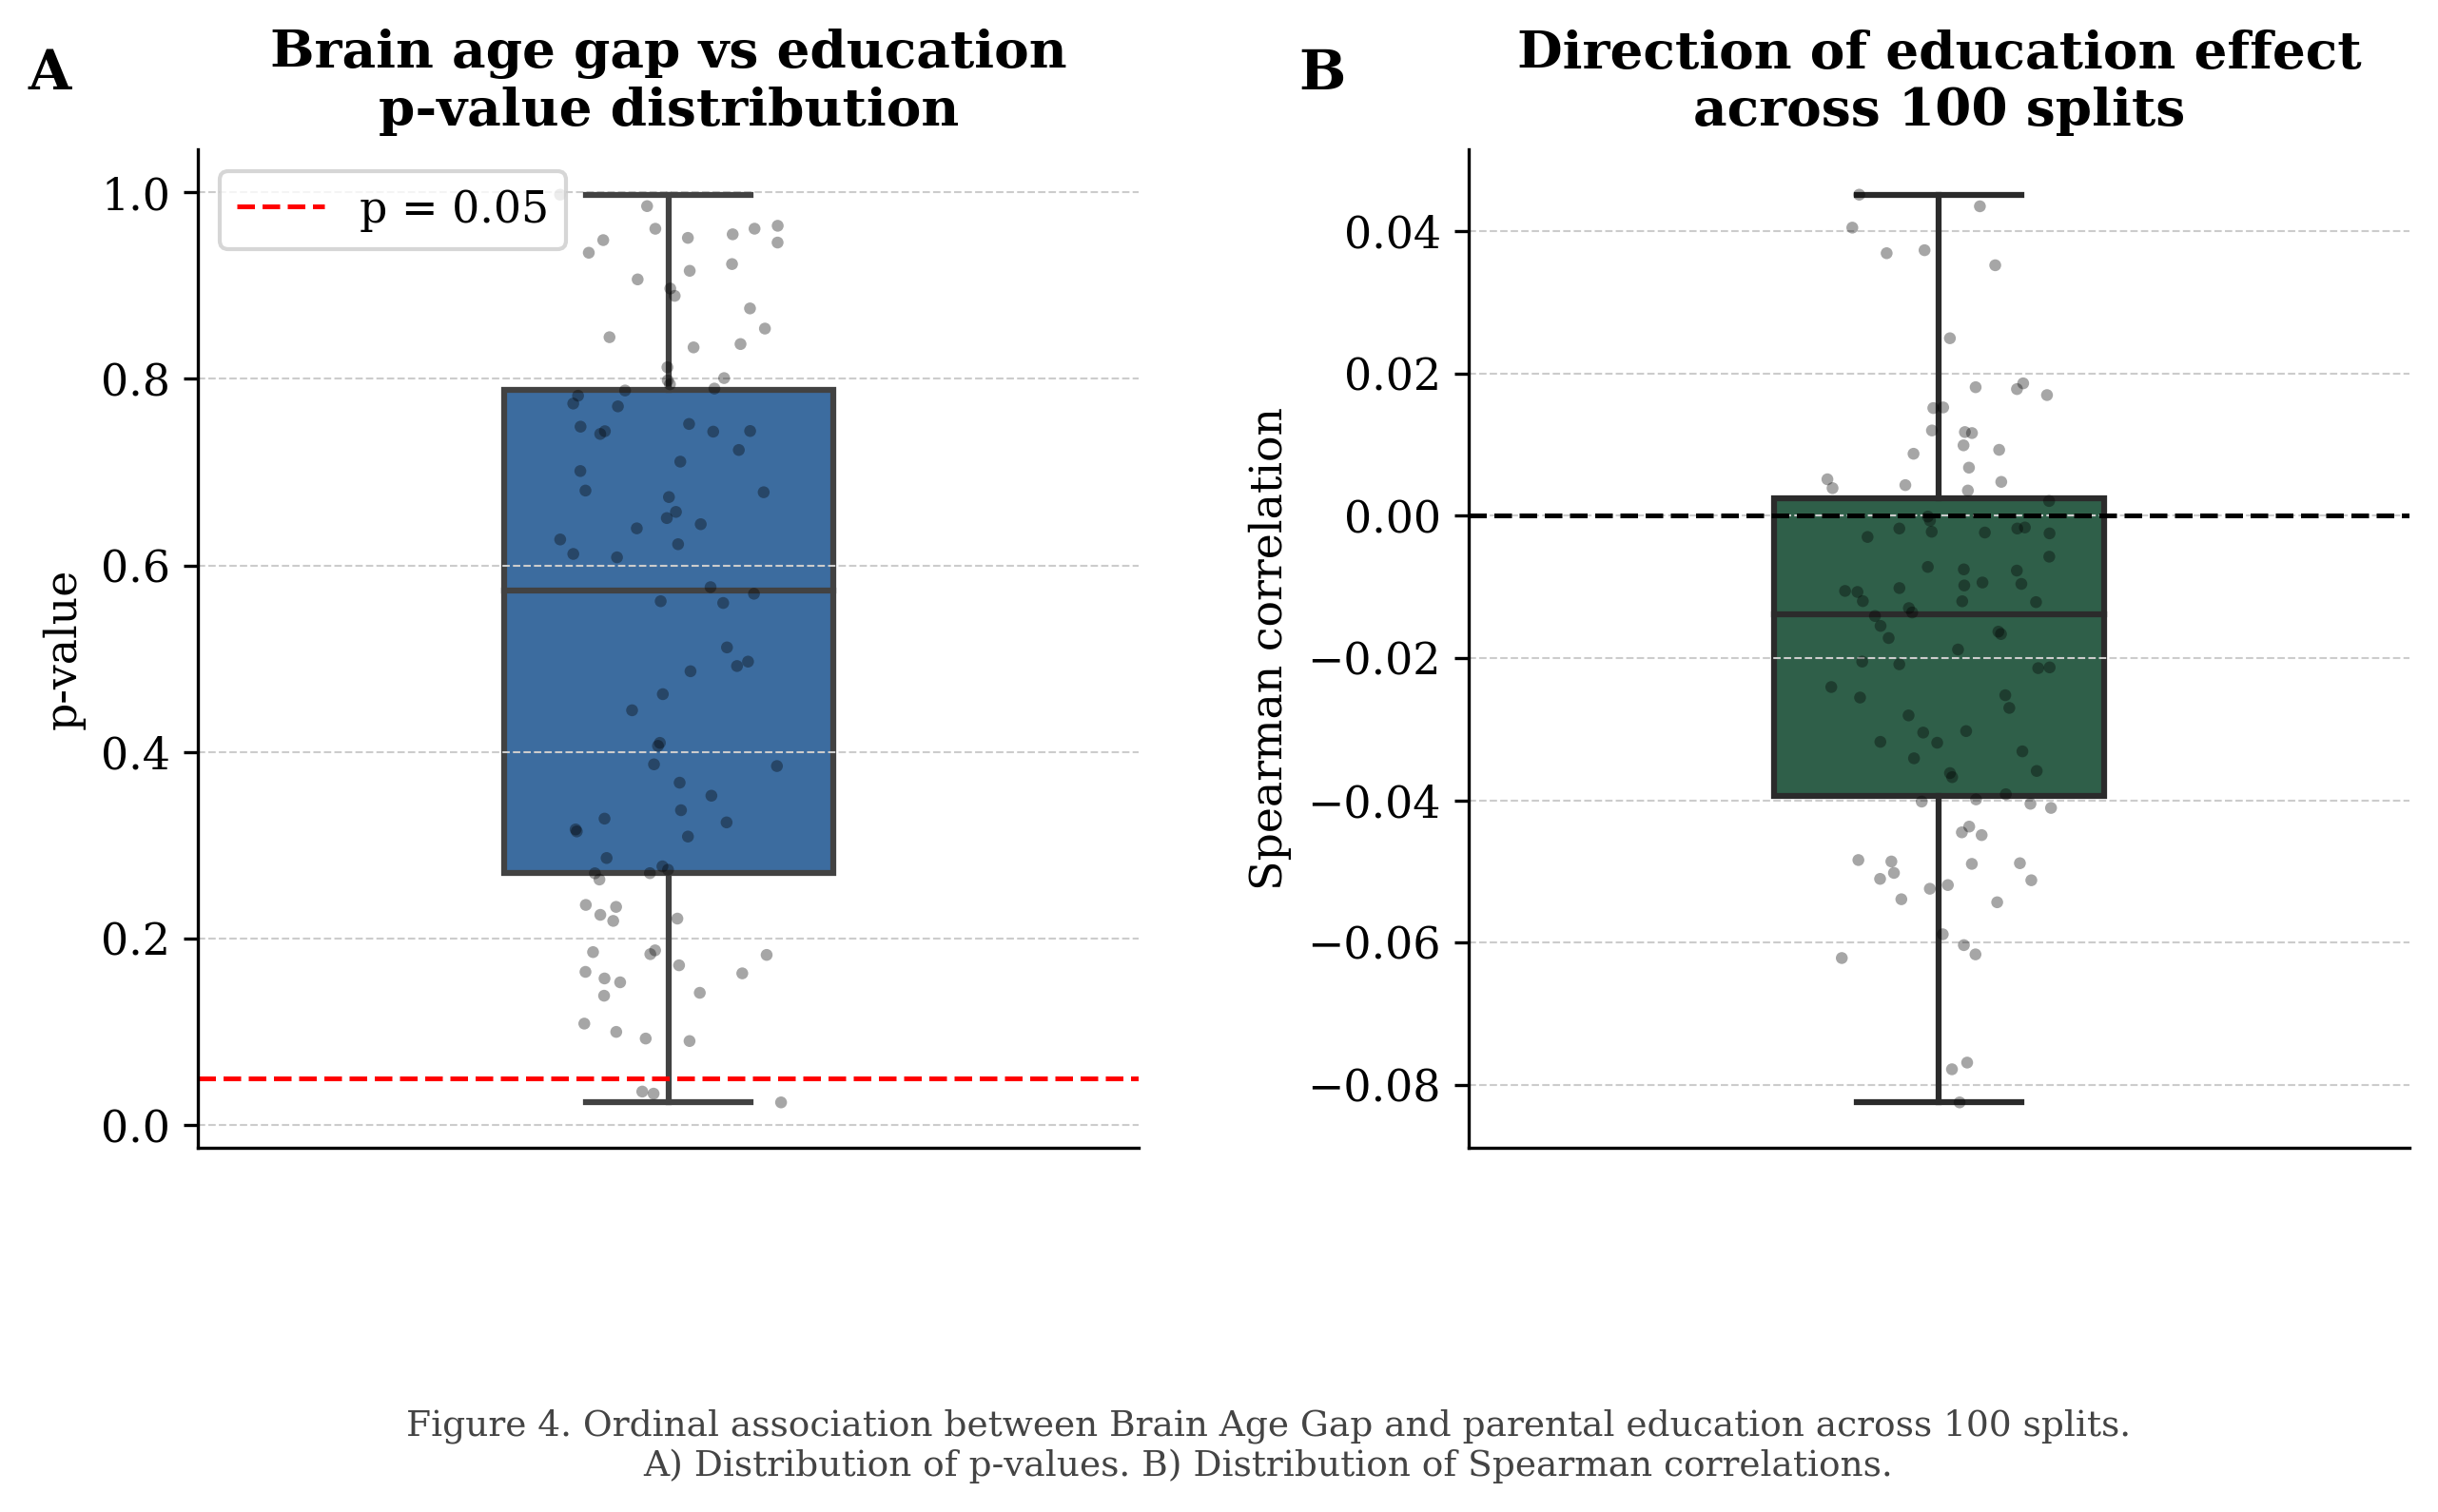

Saved!


In [16]:
# =========================================================
# BOXPLOT VERSION
# =========================================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)
fig.subplots_adjust(wspace=0.35)

# Panel A — p-value distribution
ax = axes[0]

sns.boxplot(
    y=df_ord["p_gap_edu"],
    color='#2B6CB0',
    width=0.35,
    ax=ax
)

sns.stripplot(
    y=df_ord["p_gap_edu"],
    color='black',
    alpha=0.35,
    size=3,
    jitter=0.12,
    ax=ax
)

ax.axhline(0.05, linestyle='--', color='red', linewidth=1.2, label='p = 0.05')
ax.set_ylabel('p-value')
ax.set_xticks([])
ax.set_title('Brain age gap vs education\np-value distribution', fontweight='bold')
ax.text(-0.18, 1.06, 'A', transform=ax.transAxes, fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', color='#cccccc', linewidth=0.5, linestyle='--')

# Panel B — correlation distribution
ax = axes[1]

sns.boxplot(
    y=df_ord["corr_gap_edu"],
    color='#276749',
    width=0.35,
    ax=ax
)

sns.stripplot(
    y=df_ord["corr_gap_edu"],
    color='black',
    alpha=0.35,
    size=3,
    jitter=0.12,
    ax=ax
)

ax.axhline(0, linestyle='--', color='black', linewidth=1.2)
ax.set_ylabel('Spearman correlation')
ax.set_xticks([])
ax.set_title('Direction of education effect\nacross 100 splits', fontweight='bold')
ax.text(-0.18, 1.06, 'B', transform=ax.transAxes, fontsize=14, fontweight='bold')
ax.grid(axis='y', color='#cccccc', linewidth=0.5, linestyle='--')

fig.text(
    0.5, -0.05,
    'Figure 4. Ordinal association between Brain Age Gap and parental education across 100 splits.\n'
    'A) Distribution of p-values. B) Distribution of Spearman correlations.',
    ha='center',
    fontsize=9,
    color='#444444'
)

plt.subplots_adjust(bottom=0.18)
plt.savefig('ordinal_regression_education_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

df_ord.to_csv("ordinal_regression_results.csv", index=False)
print("Saved!")

### New comaparison - Let’s try younger vs covered/older and older vs covered/younger.

In [17]:
from scipy.stats import ttest_ind, mannwhitneyu
import pandas as pd
import numpy as np

# 1. Select model output
out = results_full_all_cvplus["Ridge"]

y_test = out["y_test"]
lower = out["lower"]
upper = out["upper"]

# 2. Create masks
covered_mask = (y_test >= lower) & (y_test <= upper)
older_mask = y_test > upper
younger_mask = y_test < lower

# 3. Align test dataframe
df_test = df_combined.loc[y_test.index].copy()

# 4. Set parental education column
EDU_COL = "parent_max_education"

print("Education column exists:", EDU_COL in df_test.columns)

# 5. Add 3-class group labels
df_test["group_3class"] = np.where(
    covered_mask,
    "Within interval",
    np.where(
        older_mask,
        "Delayed neurodevelopment (Above BAI)",
        "Advanced neurodevelopment (Below BAI)"
    )
)

print("\nGroup counts:")
print(df_test["group_3class"].value_counts())

# 6. Professor-requested binary groups

df_test["advanced_vs_rest"] = np.where(
    younger_mask,
    "Advanced neurodevelopment (Below BAI)",
    "Within interval + Delayed"
)

df_test["delayed_vs_rest"] = np.where(
    older_mask,
    "Delayed neurodevelopment (Above BAI)",
    "Within interval + Advanced"
)

# 7. Advanced/Below vs Within+Delayed
advanced_edu = df_test.loc[
    df_test["advanced_vs_rest"] == "Advanced neurodevelopment (Below BAI)", EDU_COL
].dropna()

rest_adv_edu = df_test.loc[
    df_test["advanced_vs_rest"] == "Within interval + Delayed", EDU_COL
].dropna()

print("\nAdvanced neurodevelopment (Below BAI) vs Within interval + Delayed")
print("Advanced n:", len(advanced_edu))
print("Rest n:", len(rest_adv_edu))

if len(advanced_edu) > 1 and len(rest_adv_edu) > 1:
    print("T-test:", ttest_ind(advanced_edu, rest_adv_edu, equal_var=False))
    print("Mann-Whitney:", mannwhitneyu(advanced_edu, rest_adv_edu, alternative="two-sided"))
else:
    print("Not enough samples for test.")

# 8. Delayed/Above vs Within+Advanced
delayed_edu = df_test.loc[
    df_test["delayed_vs_rest"] == "Delayed neurodevelopment (Above BAI)", EDU_COL
].dropna()

rest_del_edu = df_test.loc[
    df_test["delayed_vs_rest"] == "Within interval + Advanced", EDU_COL
].dropna()

print("\nDelayed neurodevelopment (Above BAI) vs Within interval + Advanced")
print("Delayed n:", len(delayed_edu))
print("Rest n:", len(rest_del_edu))

if len(delayed_edu) > 1 and len(rest_del_edu) > 1:
    print("T-test:", ttest_ind(delayed_edu, rest_del_edu, equal_var=False))
    print("Mann-Whitney:", mannwhitneyu(delayed_edu, rest_del_edu, alternative="two-sided"))
else:
    print("Not enough samples for test.")

Education column exists: True

Group counts:
Within interval                          656
Delayed neurodevelopment (Above BAI)      45
Advanced neurodevelopment (Below BAI)     42
Name: group_3class, dtype: int64

Advanced neurodevelopment (Below BAI) vs Within interval + Delayed
Advanced n: 42
Rest n: 701
T-test: Ttest_indResult(statistic=-0.04250156787308627, pvalue=0.966288851754297)
Mann-Whitney: MannwhitneyuResult(statistic=15272.5, pvalue=0.6468278240075138)

Delayed neurodevelopment (Above BAI) vs Within interval + Advanced
Delayed n: 45
Rest n: 698
T-test: Ttest_indResult(statistic=0.315889361643893, pvalue=0.7533845352596217)
Mann-Whitney: MannwhitneyuResult(statistic=15985.5, pvalue=0.8216551366316691)


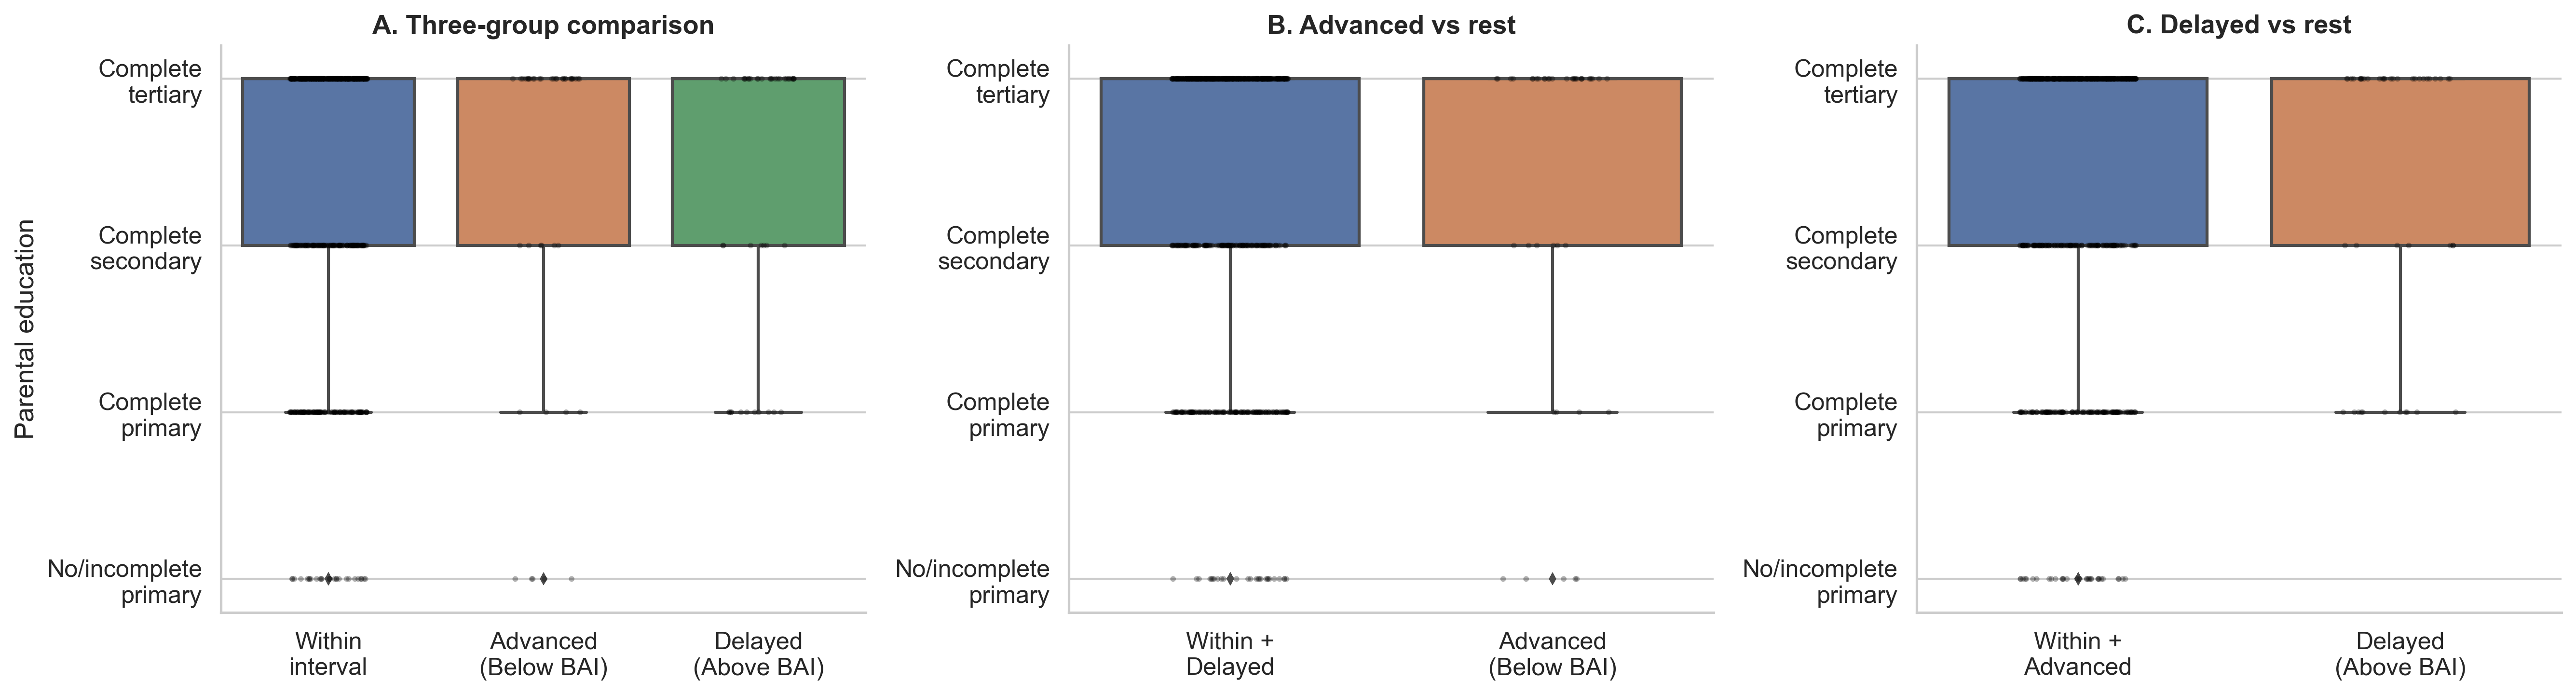

Saved: parental_education_group_boxplots.png


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

box_kws = dict(linewidth=1.5, fliersize=3)
strip_kws = dict(color="black", alpha=0.30, jitter=0.18, size=2.8)

# 1. Three-group plot
group_order = [
    "Within interval",
    "Advanced neurodevelopment (Below BAI)",
    "Delayed neurodevelopment (Above BAI)"
]

sns.boxplot(
    data=df_test,
    x="group_3class",
    y=EDU_COL,
    order=group_order,
    ax=axes[0],
    **box_kws
)

sns.stripplot(
    data=df_test,
    x="group_3class",
    y=EDU_COL,
    order=group_order,
    ax=axes[0],
    **strip_kws
)

axes[0].set_xticklabels([
    "Within\ninterval",
    "Advanced\n(Below BAI)",
    "Delayed\n(Above BAI)"
])

axes[0].set_title("A. Three-group comparison", fontsize=13, weight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Parental education")


# 2. Advanced vs rest
advanced_order = [
    "Within interval + Delayed",
    "Advanced neurodevelopment (Below BAI)"
]

sns.boxplot(
    data=df_test,
    x="advanced_vs_rest",
    y=EDU_COL,
    order=advanced_order,
    ax=axes[1],
    **box_kws
)

sns.stripplot(
    data=df_test,
    x="advanced_vs_rest",
    y=EDU_COL,
    order=advanced_order,
    ax=axes[1],
    **strip_kws
)

axes[1].set_xticklabels([
    "Within +\nDelayed",
    "Advanced\n(Below BAI)"
])

axes[1].set_title("B. Advanced vs rest", fontsize=13, weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")


# 3. Delayed vs rest
delayed_order = [
    "Within interval + Advanced",
    "Delayed neurodevelopment (Above BAI)"
]

sns.boxplot(
    data=df_test,
    x="delayed_vs_rest",
    y=EDU_COL,
    order=delayed_order,
    ax=axes[2],
    **box_kws
)

sns.stripplot(
    data=df_test,
    x="delayed_vs_rest",
    y=EDU_COL,
    order=delayed_order,
    ax=axes[2],
    **strip_kws
)

axes[2].set_xticklabels([
    "Within +\nAdvanced",
    "Delayed\n(Above BAI)"
])

axes[2].set_title("C. Delayed vs rest", fontsize=13, weight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

for ax in axes:
    ax.set_ylim(-0.2, 3.2)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels([
        "No/incomplete\nprimary",
        "Complete\nprimary",
        "Complete\nsecondary",
        "Complete\ntertiary"
    ])
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("parental_education_group_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: parental_education_group_boxplots.png")

### 100-splits comparisions

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, ttest_ind, kruskal
from sklearn.model_selection import train_test_split, KFold
from sklearn.base import clone

# ---- config ----
N_SPLITS = 100
ALPHA    = 0.1
N_FOLDS  = 5
EDU_COL  = "parent_max_education"

ridge_model = models["Ridge"]

def rank_biserial(U, n1, n2):
    return 1 - 2 * U / (n1 * n2)

def run_contrast(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) < 2 or len(b) < 2:
        return dict(n1=len(a), n2=len(b), U=np.nan, p_mwu=np.nan,
                    rb=np.nan, t=np.nan, p_t=np.nan,
                    med_a=np.nan, med_b=np.nan,
                    mean_a=np.nan, mean_b=np.nan)
    mwu = mannwhitneyu(a, b, alternative="two-sided")
    tt  = ttest_ind(a, b, equal_var=False)
    return dict(n1=len(a), n2=len(b),
                U=float(mwu.statistic), p_mwu=float(mwu.pvalue),
                rb=float(rank_biserial(mwu.statistic, len(a), len(b))),
                t=float(tt.statistic), p_t=float(tt.pvalue),
                med_a=float(np.median(a)), med_b=float(np.median(b)),
                mean_a=float(np.mean(a)),  mean_b=float(np.mean(b)))

records = []
for seed in range(N_SPLITS):
    # ---- train/test split + CV+ conformal ----
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    lo_blocks, up_blocks = [], []
    for tr_idx, val_idx in cv.split(X_tr):
        m = clone(ridge_model)
        m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        resid = np.abs(y_tr.iloc[val_idx].to_numpy() - m.predict(X_tr.iloc[val_idx]))
        yhat  = m.predict(X_te)
        lo_blocks.append(yhat[None, :] - resid[:, None])
        up_blocks.append(yhat[None, :] + resid[:, None])
    lower = np.quantile(np.vstack(lo_blocks), ALPHA,     axis=0)
    upper = np.quantile(np.vstack(up_blocks), 1 - ALPHA, axis=0)

    # ---- masks ----
    y_arr   = y_te.to_numpy()
    covered = (y_arr >= lower) & (y_arr <= upper)
    older   = y_arr > upper
    younger = y_arr < lower

    df_te    = df_combined.loc[y_te.index]
    edu_vals = df_te[EDU_COL].to_numpy()
    ok       = ~pd.isna(edu_vals)

    n_cov, n_yng, n_old = int(covered.sum()), int(younger.sum()), int(older.sum())

    # Younger vs Covered+Older
    r = run_contrast(edu_vals[younger & ok], edu_vals[~younger & ok])
    records.append({"seed": seed, "contrast": "younger_vs_rest", **r,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    # Older vs Covered+Younger
    r = run_contrast(edu_vals[older & ok], edu_vals[~older & ok])
    records.append({"seed": seed, "contrast": "older_vs_rest", **r,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    # 3-class Kruskal-Wallis
    cov_vals = edu_vals[covered & ok]
    yng_vals = edu_vals[younger & ok]
    old_vals = edu_vals[older   & ok]
    if len(cov_vals) > 1 and len(yng_vals) > 1 and len(old_vals) > 1:
        kw = kruskal(cov_vals, yng_vals, old_vals)
        kw_p = float(kw.pvalue)
    else:
        kw_p = np.nan
    records.append({"seed": seed, "contrast": "kruskal_3class",
                    "n1": n_cov + n_yng + n_old, "n2": np.nan,
                    "U": np.nan, "p_mwu": kw_p,
                    "rb": np.nan, "t": np.nan, "p_t": np.nan,
                    "med_a": np.nan, "med_b": np.nan,
                    "mean_a": np.nan, "mean_b": np.nan,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    if (seed + 1) % 10 == 0:
        print(f"  finished split {seed+1}/{N_SPLITS}")

split_results_edu = pd.DataFrame(records)
split_results_edu.to_csv("education_comparisons_100splits.csv", index=False)
print("\nDone. Shape:", split_results_edu.shape)

  finished split 10/100
  finished split 20/100
  finished split 30/100
  finished split 40/100
  finished split 50/100
  finished split 60/100
  finished split 70/100
  finished split 80/100
  finished split 90/100
  finished split 100/100

Done. Shape: (300, 16)


In [10]:
summary_edu = (
    split_results_edu
    .groupby("contrast")
    .agg(
        median_p     = ("p_mwu", "median"),
        p_5          = ("p_mwu", lambda x: np.quantile(x.dropna(), 0.05)),
        p_95         = ("p_mwu", lambda x: np.quantile(x.dropna(), 0.95)),
        frac_p_lt_05 = ("p_mwu", lambda x: (x < 0.05).mean()),
        median_rb    = ("rb",    "median"),
        rb_5         = ("rb",    lambda x: np.quantile(x.dropna(), 0.05) if x.notna().any() else np.nan),
        rb_95        = ("rb",    lambda x: np.quantile(x.dropna(), 0.95) if x.notna().any() else np.nan),
        mean_n_group = ("n1",    "mean"),
        mean_n_rest  = ("n2",    "mean"),
    )
    .reset_index()
)
print(summary_edu.to_string(index=False))
summary_edu.to_csv("education_summary_100splits.csv", index=False)

       contrast  median_p      p_5     p_95  frac_p_lt_05  median_rb      rb_5    rb_95  mean_n_group  mean_n_rest
 kruskal_3class  0.241606 0.014879 0.854298          0.14        NaN       NaN      NaN        743.00          NaN
  older_vs_rest  0.304012 0.016287 0.924830          0.19   0.089919 -0.029389 0.207490         39.97       703.03
younger_vs_rest  0.386057 0.024802 0.822445          0.08   0.083458 -0.057306 0.205274         29.62       713.38


X shape: (3484, 829)
Education cols in X: ['parent_2_education_numeric']
p_factor cols in X: []
parent cols in X: ['parent_2_education_numeric']


### The left figure is hard to interpret. Can you instead just report the percentage of p<0.05 (aka power) as a bar graph?

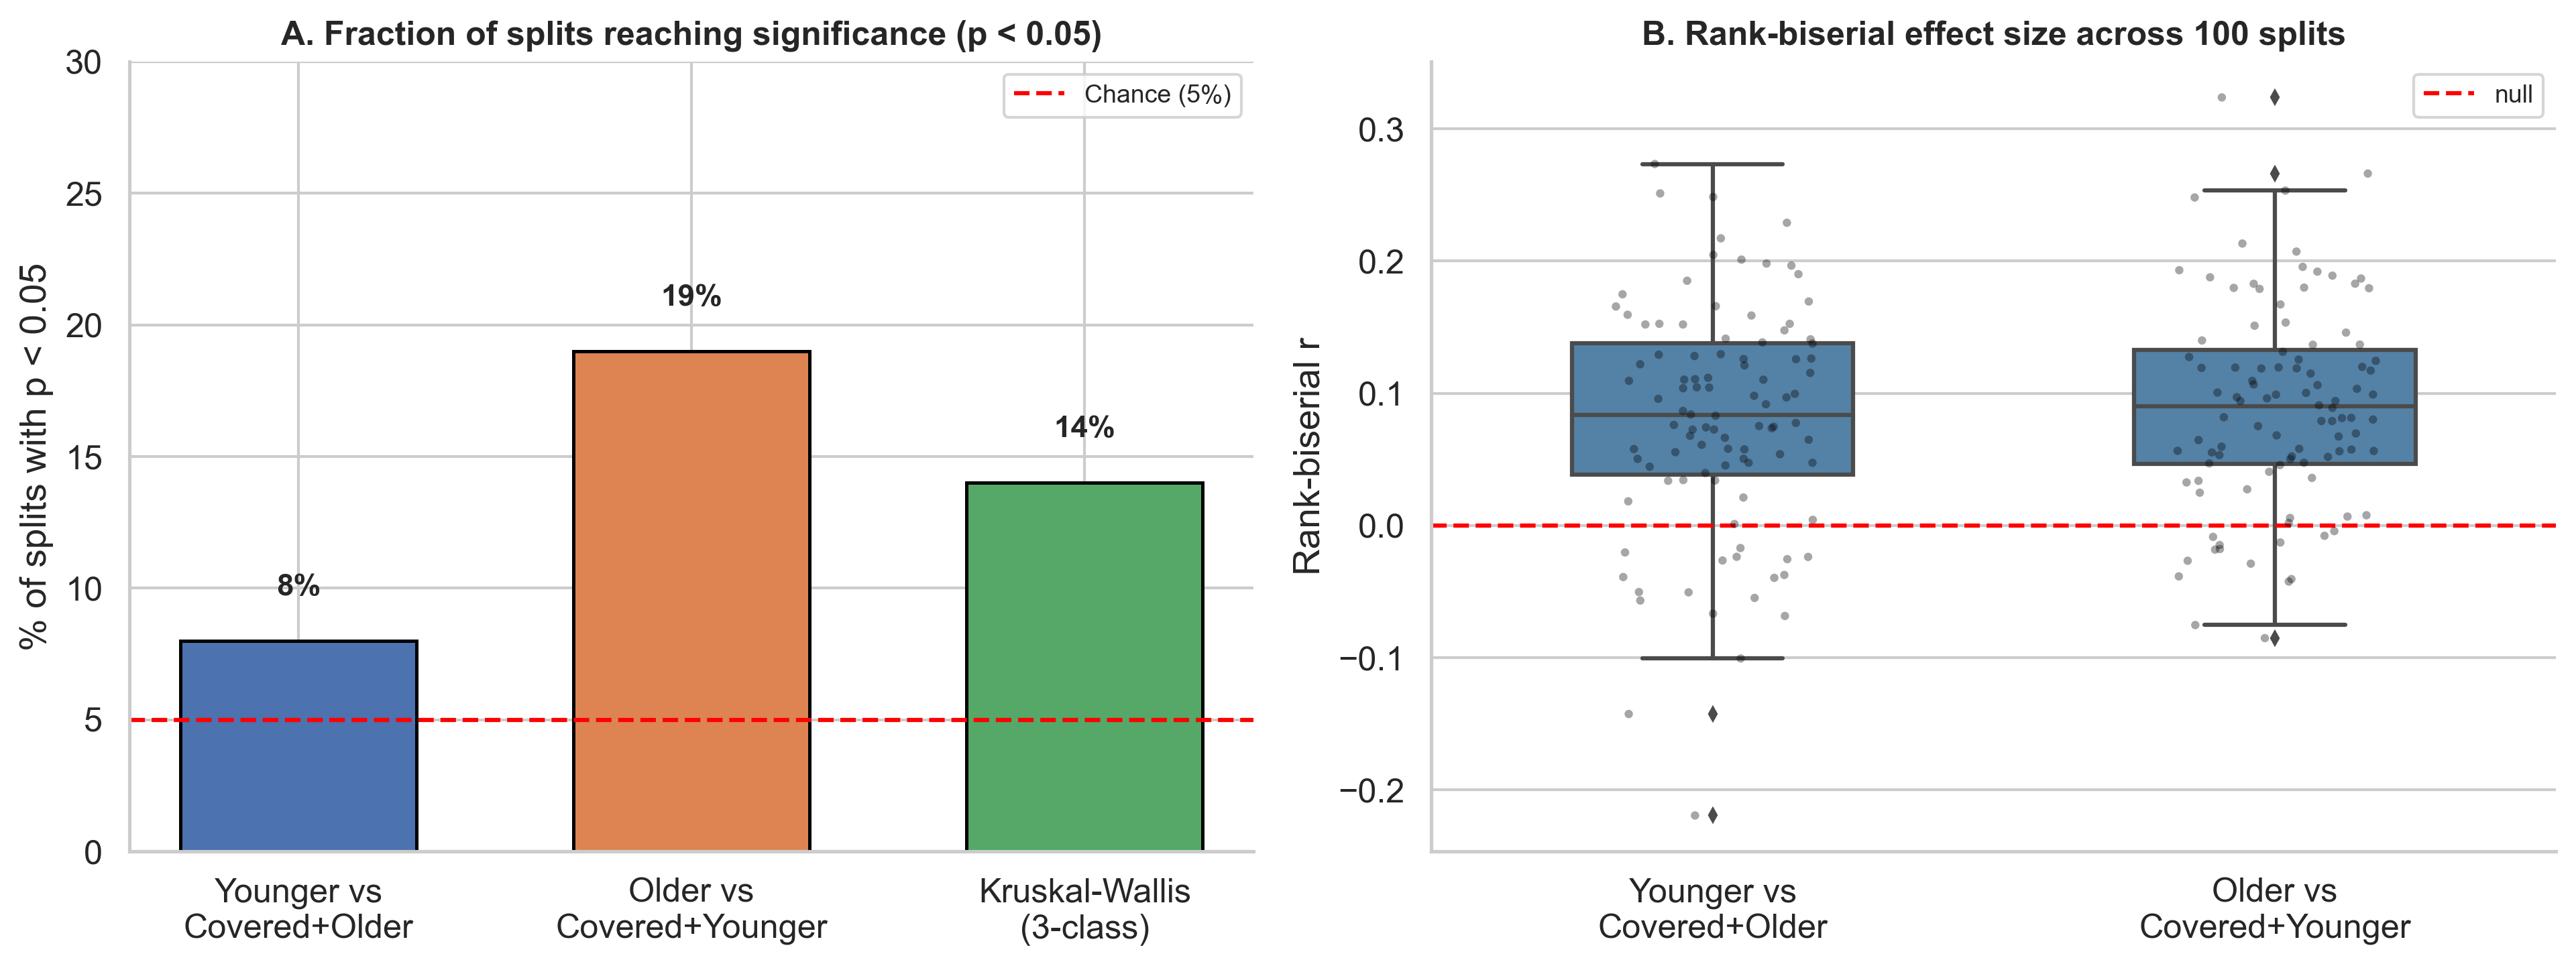

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

contrast_order  = ["younger_vs_rest", "older_vs_rest", "kruskal_3class"]
contrast_labels = ["Younger vs\nCovered+Older",
                   "Older vs\nCovered+Younger",
                   "Kruskal-Wallis\n(3-class)"]

# Compute % of splits with p < 0.05
frac_sig = (
    split_results_edu
    .groupby("contrast")["p_mwu"]
    .apply(lambda x: (x < 0.05).mean() * 100)
    .reindex(contrast_order)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

# ---- Panel A: bar graph of % significant ----
bar_colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = axes[0].bar(contrast_labels, frac_sig.values,
                   color=bar_colors, edgecolor="black", linewidth=1.2, width=0.6)

for bar, val in zip(bars, frac_sig.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 1.5,
                 f"{val:.0f}%", ha="center", va="bottom",
                 fontsize=11, weight="bold")

axes[0].axhline(5, color="red", linestyle="--", linewidth=1.5,
                label="Chance (5%)")
axes[0].set_ylim(0, max(frac_sig.max() + 10, 30))
axes[0].set_ylabel("% of splits with p < 0.05")
axes[0].set_title("A. Fraction of splits reaching significance (p < 0.05)",
                  weight="bold", fontsize=12)
axes[0].legend(fontsize=9, loc="upper right")

# ---- Panel B: rank-biserial effect sizes (unchanged) ----
binary_df = split_results_edu[split_results_edu["contrast"] != "kruskal_3class"]
sns.boxplot(data=binary_df, x="contrast", y="rb",
            order=contrast_order[:2], ax=axes[1],
            width=0.5, linewidth=1.5, fliersize=3, color="steelblue")
sns.stripplot(data=binary_df, x="contrast", y="rb",
              order=contrast_order[:2], ax=axes[1],
              color="black", alpha=0.35, size=3, jitter=0.18)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5, label="null")
axes[1].set_title("B. Rank-biserial effect size across 100 splits",
                  weight="bold", fontsize=12)
axes[1].set_xlabel(""); axes[1].set_ylabel("Rank-biserial r")
axes[1].set_xticklabels(contrast_labels[:2])
axes[1].legend(fontsize=9)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("education_100splits_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

In [2]:
# ============================================================
# END-TO-END: parental education 100-split CV+ (Ridge) →
# save p-value CSV → apply BH correction → print counts
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from scipy.stats import mannwhitneyu, ttest_ind, kruskal
from statsmodels.stats.multitest import multipletests


# ============================================================
# 1. Load and merge datasets
# ============================================================

fc_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_withinbetween_fcrsn7_artifact_pfactor_filter_harmonized.tsv"
gv_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_gv_artifact_pfactor_filter_harmonized.tsv"
ct_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_ct_artifact_pfactor_filter_harmonized.tsv"

df_fc = pd.read_csv(fc_path, sep="\t")
df_gv = pd.read_csv(gv_path, sep="\t")
df_ct = pd.read_csv(ct_path, sep="\t")

# Keep both parent education columns for max computation
df_fc_cleaned = df_fc.drop(columns=[
    'study', 'study_site', 'session_id', 'wave', 'ethnicity', 'sex', 'race',
    'handedness', 'bmi', 'participant_education',
    'internalizing_mcelroy_harmonized_all_samples',
    'externalizing_mcelroy_harmonized_all_samples',
    'attention_mcelroy_harmonized_all_samples',
    'cubids_acquisition_group', 'medianFD', 'meanFD'
])

df_gv_cleaned = df_gv.loc[:, df_gv.columns.str.startswith('7Networks_') |
                             df_gv.columns.isin(['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'])]
df_ct_cleaned = df_ct.loc[:, df_ct.columns.str.startswith('7Networks_') |
                             df_ct.columns.isin(['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'])]

df_combined = pd.merge(df_fc_cleaned, df_gv_cleaned,
                       on=['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'],
                       how='inner')
df_combined = pd.merge(df_combined, df_ct_cleaned,
                       on=['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'],
                       how='inner')

# Compute parent_max_education = max of parent_1 and parent_2
education_mapping = {
    'Complete tertiary': 3,
    'Complete secondary': 2,
    'Complete primary': 1,
    'No/incomplete primary': 0
}
p1_num = df_combined['parent_1_education'].map(education_mapping)
p2_num = df_combined['parent_2_education'].map(education_mapping)
df_combined['parent_max_education'] = pd.concat([p1_num, p2_num], axis=1).max(axis=1)

df_combined = df_combined.drop(columns=['parent_1_education', 'parent_2_education'])

# Keep participants with at least one parent's education available
before = len(df_combined)
df_combined = df_combined.dropna(subset=['parent_max_education'])
print(f"After dropping participants with no parental education: {before} → {len(df_combined)}")


# ============================================================
# 2. Prepare X, y
# ============================================================

X = df_combined.drop(columns=[
    'age',
    'participant_id',
    'p_factor_mcelroy_harmonized_all_samples',
    'parent_max_education',
])
y = df_combined['age']

print(f"X shape: {X.shape}, y shape: {y.shape}")


# ============================================================
# 3. Define Ridge model
# ============================================================

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 30)))
])


# ============================================================
# 4. Run 100-split CV+ + three contrasts on parental education
# ============================================================

N_SPLITS = 100
ALPHA    = 0.1
N_FOLDS  = 5
EDU_COL  = "parent_max_education"


def rank_biserial(U, n1, n2):
    return 1 - 2 * U / (n1 * n2)


def run_contrast(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) < 2 or len(b) < 2:
        return dict(n1=len(a), n2=len(b), U=np.nan, p_mwu=np.nan,
                    rb=np.nan, t=np.nan, p_t=np.nan,
                    med_a=np.nan, med_b=np.nan,
                    mean_a=np.nan, mean_b=np.nan)
    mwu = mannwhitneyu(a, b, alternative="two-sided")
    tt  = ttest_ind(a, b, equal_var=False)
    return dict(n1=len(a), n2=len(b),
                U=float(mwu.statistic), p_mwu=float(mwu.pvalue),
                rb=float(rank_biserial(mwu.statistic, len(a), len(b))),
                t=float(tt.statistic), p_t=float(tt.pvalue),
                med_a=float(np.median(a)), med_b=float(np.median(b)),
                mean_a=float(np.mean(a)),  mean_b=float(np.mean(b)))


records = []
for seed in range(N_SPLITS):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    lo_blocks, up_blocks = [], []
    for tr_idx, val_idx in cv.split(X_tr):
        m = clone(ridge_model)
        m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        resid = np.abs(y_tr.iloc[val_idx].to_numpy() - m.predict(X_tr.iloc[val_idx]))
        yhat  = m.predict(X_te)
        lo_blocks.append(yhat[None, :] - resid[:, None])
        up_blocks.append(yhat[None, :] + resid[:, None])

    lower = np.quantile(np.vstack(lo_blocks), ALPHA,     axis=0)
    upper = np.quantile(np.vstack(up_blocks), 1 - ALPHA, axis=0)

    y_arr    = y_te.to_numpy()
    covered  = (y_arr >= lower) & (y_arr <= upper)
    older    = y_arr > upper
    younger  = y_arr < lower

    df_te    = df_combined.loc[y_te.index]
    edu_vals = df_te[EDU_COL].to_numpy()
    ok       = ~pd.isna(edu_vals)

    n_cov = int(covered.sum()); n_yng = int(younger.sum()); n_old = int(older.sum())

    # younger vs (covered + older)
    r = run_contrast(edu_vals[younger & ok], edu_vals[~younger & ok])
    records.append({"seed": seed, "contrast": "younger_vs_rest", **r,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    # older vs (covered + younger)
    r = run_contrast(edu_vals[older & ok], edu_vals[~older & ok])
    records.append({"seed": seed, "contrast": "older_vs_rest", **r,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    # 3-class Kruskal-Wallis
    cov_vals = edu_vals[covered & ok]
    yng_vals = edu_vals[younger & ok]
    old_vals = edu_vals[older   & ok]
    if len(cov_vals) > 1 and len(yng_vals) > 1 and len(old_vals) > 1:
        kw = kruskal(cov_vals, yng_vals, old_vals)
        kw_p = float(kw.pvalue)
    else:
        kw_p = np.nan
    records.append({"seed": seed, "contrast": "kruskal_3class",
                    "n1": n_cov + n_yng + n_old, "n2": np.nan,
                    "U": np.nan, "p_mwu": kw_p,
                    "rb": np.nan, "t": np.nan, "p_t": np.nan,
                    "med_a": np.nan, "med_b": np.nan,
                    "mean_a": np.nan, "mean_b": np.nan,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    if (seed + 1) % 10 == 0:
        print(f"  finished split {seed + 1}/{N_SPLITS}")

split_results = pd.DataFrame(records)
split_results.to_csv("education_comparisons_100splits.csv", index=False)
print(f"\nSaved: education_comparisons_100splits.csv, shape {split_results.shape}")


# ============================================================
# 5. Apply BH correction — TWO versions
#    Version A: across 3 tests (older, younger, Kruskal)
#    Version B: across 2 tests (older, younger — dropping Kruskal per Golia)
# ============================================================

pvals_wide = split_results.pivot(index="seed", columns="contrast", values="p_mwu")

# --- Version A: across all 3 tests ---
contrasts_3 = ["older_vs_rest", "younger_vs_rest", "kruskal_3class"]
pv3 = pvals_wide[contrasts_3]
bh_sig_3 = np.zeros_like(pv3.values, dtype=bool)
for i, row in enumerate(pv3.values):
    bh_sig_3[i, :] = multipletests(row, alpha=0.05, method="fdr_bh")[0]

# --- Version B: across 2 tests only ---
contrasts_2 = ["older_vs_rest", "younger_vs_rest"]
pv2 = pvals_wide[contrasts_2]
bh_sig_2 = np.zeros_like(pv2.values, dtype=bool)
for i, row in enumerate(pv2.values):
    bh_sig_2[i, :] = multipletests(row, alpha=0.05, method="fdr_bh")[0]

print("\n" + "=" * 60)
print("Splits with p < 0.05 (out of 100) — PARENTAL EDUCATION")
print("=" * 60)

print("\nUncorrected:")
for c in contrasts_3:
    print(f"  {c}: {(pvals_wide[c] < 0.05).sum()}/100")

print("\nBH corrected (across 3 tests — for reference):")
for j, c in enumerate(contrasts_3):
    print(f"  {c}: {bh_sig_3[:, j].sum()}/100")

print("\nBH corrected (across 2 tests — Kruskal dropped, use this):")
for j, c in enumerate(contrasts_2):
    print(f"  {c}: {bh_sig_2[:, j].sum()}/100")

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_86087/493393270.py:27: DtypeWarning: Columns (405) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gv = pd.read_csv(gv_path, sep="\t")
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_86087/493393270.py:28: DtypeWarning: Columns (405) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ct = pd.read_csv(ct_path, sep="\t")


After dropping participants with no parental education: 3762 → 3712
X shape: (3712, 828), y shape: (3712,)
  finished split 10/100
  finished split 20/100
  finished split 30/100
  finished split 40/100
  finished split 50/100
  finished split 60/100
  finished split 70/100
  finished split 80/100
  finished split 90/100
  finished split 100/100

Saved: education_comparisons_100splits.csv, shape (300, 16)

Splits with p < 0.05 (out of 100) — PARENTAL EDUCATION

Uncorrected:
  older_vs_rest: 19/100
  younger_vs_rest: 8/100
  kruskal_3class: 14/100

BH corrected (across 3 tests — for reference):
  older_vs_rest: 7/100
  younger_vs_rest: 4/100
  kruskal_3class: 9/100

BH corrected (across 2 tests — Kruskal dropped, use this):
  older_vs_rest: 9/100
  younger_vs_rest: 5/100


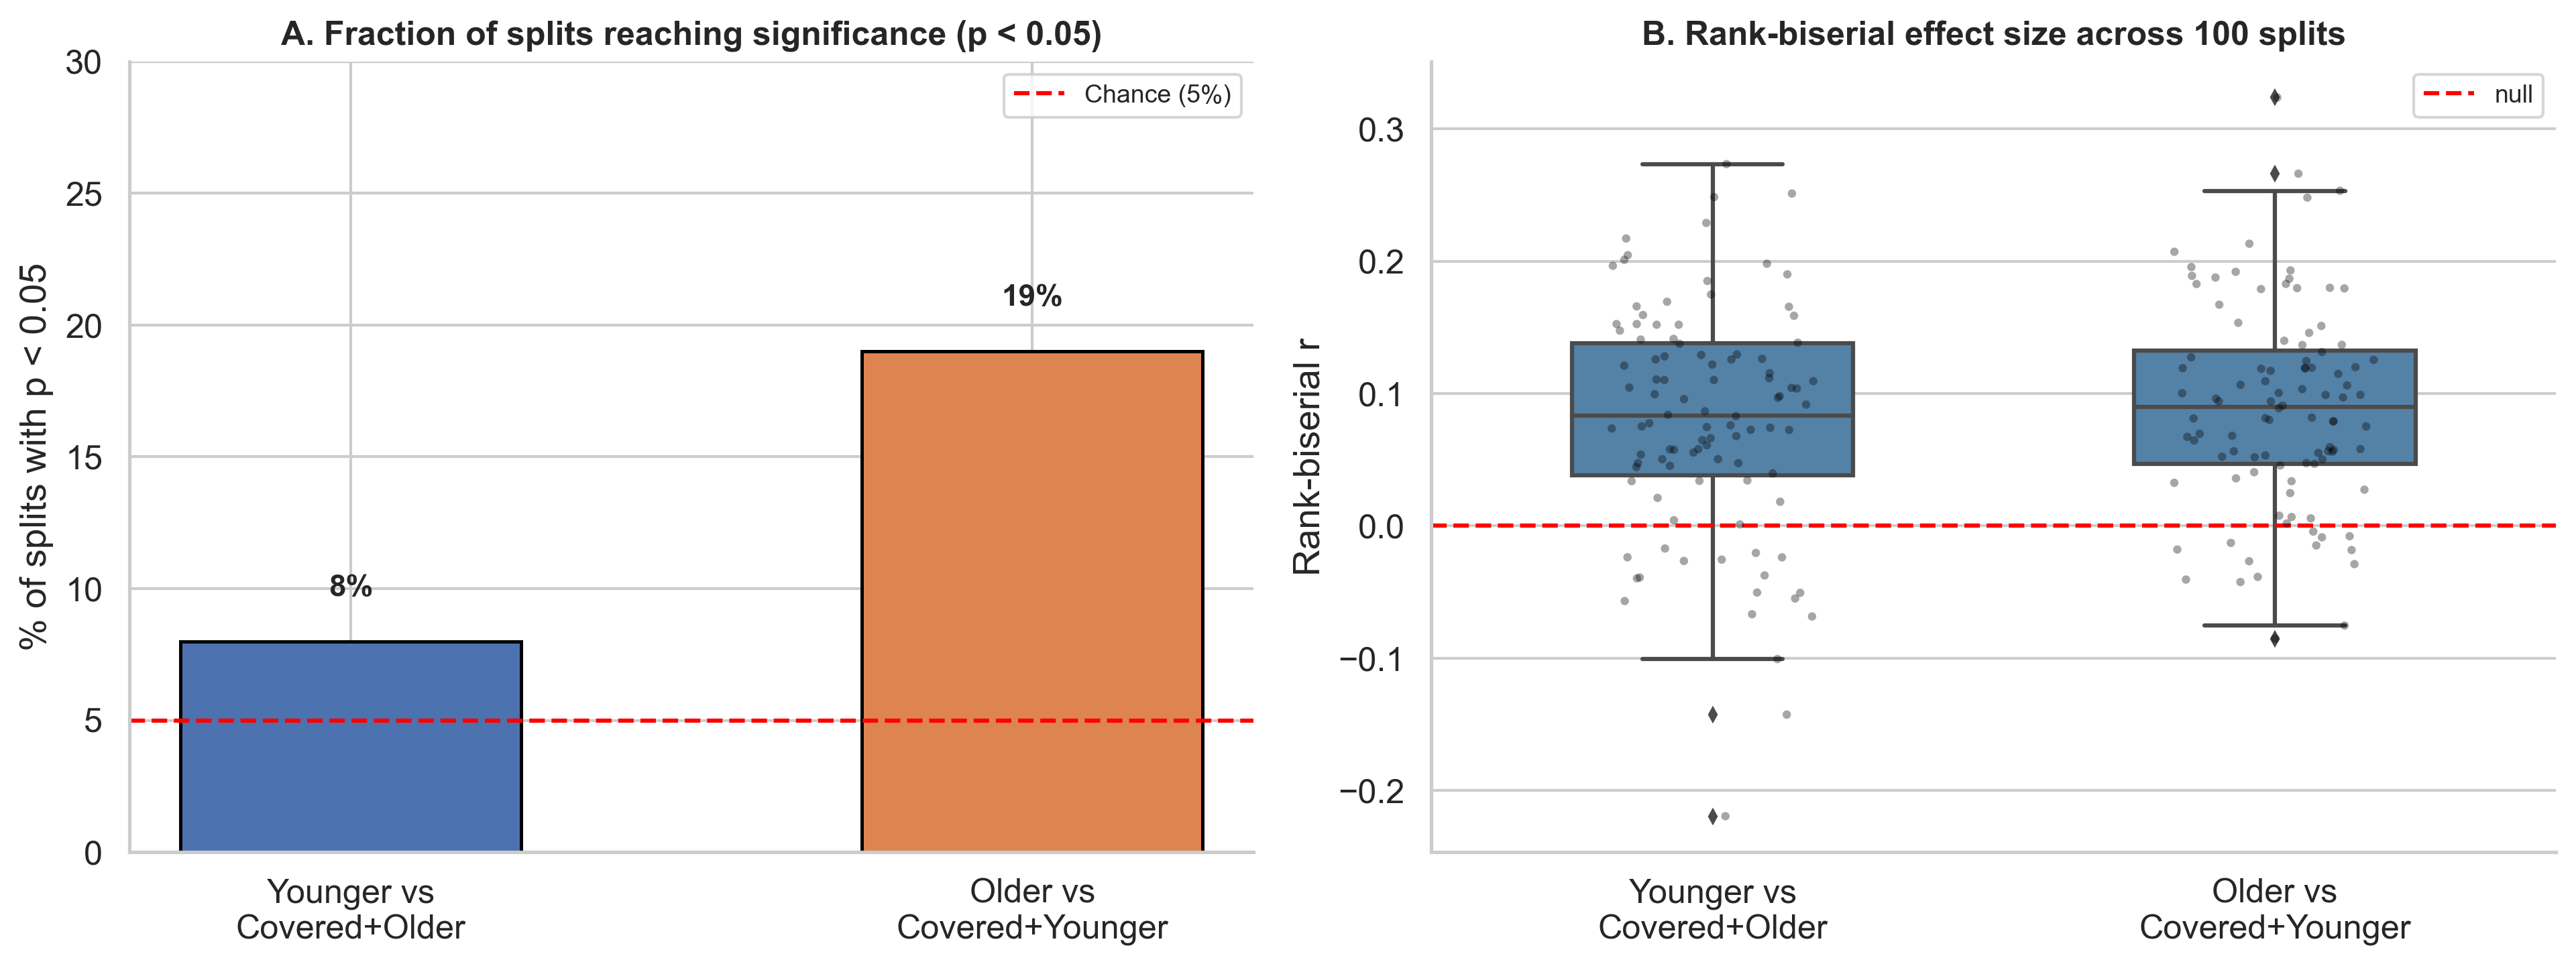

Saved: /Users/ujjwalsamanta/Desktop/figure5_education_100splits.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

# Only 2 contrasts now (Kruskal removed per Golia's comment)
contrast_order  = ["younger_vs_rest", "older_vs_rest"]
contrast_labels = ["Younger vs\nCovered+Older",
                   "Older vs\nCovered+Younger"]

# Compute % of splits with p < 0.05
frac_sig = (
    split_results
    .groupby("contrast")["p_mwu"]
    .apply(lambda x: (x < 0.05).mean() * 100)
    .reindex(contrast_order)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

# ---- Panel A: bar graph of % significant ----
bar_colors = ["#4C72B0", "#DD8452"]
bars = axes[0].bar(contrast_labels, frac_sig.values,
                   color=bar_colors, edgecolor="black", linewidth=1.2, width=0.5)

for bar, val in zip(bars, frac_sig.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 1.5,
                 f"{val:.0f}%", ha="center", va="bottom",
                 fontsize=11, weight="bold")

axes[0].axhline(5, color="red", linestyle="--", linewidth=1.5,
                label="Chance (5%)")
axes[0].set_ylim(0, max(frac_sig.max() + 10, 30))
axes[0].set_ylabel("% of splits with p < 0.05")
axes[0].set_title("A. Fraction of splits reaching significance (p < 0.05)",
                  weight="bold", fontsize=12)
axes[0].legend(fontsize=9, loc="upper right")

# ---- Panel B: rank-biserial effect sizes ----
binary_df = split_results[split_results["contrast"].isin(contrast_order)]
sns.boxplot(data=binary_df, x="contrast", y="rb",
            order=contrast_order, ax=axes[1],
            width=0.5, linewidth=1.5, fliersize=3, color="steelblue")
sns.stripplot(data=binary_df, x="contrast", y="rb",
              order=contrast_order, ax=axes[1],
              color="black", alpha=0.35, size=3, jitter=0.18)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5, label="null")
axes[1].set_title("B. Rank-biserial effect size across 100 splits",
                  weight="bold", fontsize=12)
axes[1].set_xlabel(""); axes[1].set_ylabel("Rank-biserial r")
axes[1].set_xticklabels(contrast_labels)
axes[1].legend(fontsize=9)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()

# Save to Desktop
png_path = "/Users/ujjwalsamanta/Desktop/figure5_education_100splits.png"
plt.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")

plt.show()
print(f"Saved: {png_path}")